# ALeRCE LSST + ZTF queries

```Author: Alejandra Muñoz Arancibia. Last updated: 260311```

This notebook shows how to query both Rubin and ZTF alert stream data (as well as derived properties) stored by the ALeRCE broker. We show examples of queries to our databases tables via: the ALeRCE python client (for both LSST and ZTF), Astronomical Data Query Language (ADQL) queries to the ALeRCE Table Access Protocol (TAP) service (for LSST), and Structured Query Language (SQL) queries to our PostgreSQL database (for ZTF). We use the pandas package to manipulate output tables as dataframes.

We refer to [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/Meetings/ALeRCE_HackFest_2026/ALeRCE_LSST_Tables.ipynb) for a detailed description of how Rubin data are stored in the ALeRCE multistream database. The ALeRCE python client is described in more detail in [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/Meetings/ALeRCE_HackFest_2026/ALeRCE_LSST_Client_Queries.ipynb). Advanced queries not yet available for the python client can be done using Astronomical Data Query Language (ADQL) queries to the ALeRCE Table Access Protocol (TAP) service, as described in detail in [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/Meetings/ALeRCE_HackFest_2026/ALeRCE_LSST_TAP_Queries.ipynb).

*It is highly recommended that you try this notebook in Google Colab using the following [link](https://colab.research.google.com/github/alercebroker/usecases/blob/master/notebooks/Meetings/ALeRCE_HackFest_2026/ALeRCE_LSST_ZTF.ipynb).* This will avoid you from having to sort out library installation problems and focus on the contents of the tutorial. You can try installing the dependencies later in your own system.

# Table of contents

* [Before starting](#before)
    * [Some settings](#settings)
    * [Initialize the ALeRCE client](#client)
    * [Connect to ALeRCE data via TAP](#tap)
    * [LSST queries to the ALeRCE multisurvey database](#multisurvey)
    * [Types of object identifiers](#sid)
* [How to query LSST and ZTF data for a given object](#query_one_lsst_ztf)
    * [Light curves](#light_curves)
    * [Features](#features)

## Before starting <a class='anchor' id='before'></a>

### Some settings <a class='anchor' id='settings'></a>

Install the [ALeRCE python client](https://alerce.readthedocs.io/en/latest/) uncommenting the following line. In case you have a previous alerce package version, note that you need to update it to version 2.2.1 or newer to retrieve Rubin data.

In [1]:
#!pip install alerce

We also use custom functions defined in ```lib_multisurvey```. In case you are using Google Colab, download this uncommenting the following line.

In [2]:
#!wget https://raw.githubusercontent.com/alercebroker/usecases/master/notebooks/Meetings/ALeRCE_HackFest_2026/lib_multisurvey/alerce_multisurvey_tools.py -P lib_multisurvey/

Load libraries

In [3]:
#!pip install pyvo
#!pip install requests
#!pip install sqlalchemy
#!pip install psycopg2-binary

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18
import pyvo as vo
import requests
import sqlalchemy as sa
import sys

In [5]:
from IPython.core.display import HTML
pd.set_option('display.max_colwidth', 1000)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

In [6]:
from alerce.core import Alerce

### Initialize the ALeRCE client <a class='anchor' id='client'></a>

In [7]:
alerce_client = Alerce()

### Connect to ALeRCE data via TAP <a class='anchor' id='tap'></a>

We connect to the [ALeRCE TAP service](https://tap.alerce.online/) as

In [8]:
alerce_tap = vo.dal.TAPService('https://tap.alerce.online/tap')

### LSST queries to the ALeRCE multisurvey database <a class='anchor' id='multisurvey'></a>

We save Rubin alert stream data in a multisurvey database. We distinguish among data sources by using the field ```tid```, for "telescope identifier". LSST (and more generally, all Rubin data observed with the Simonyi telescope) has ```tid = 1```.

In [9]:
tid = 1

### Types of object identifiers <a class='anchor' id='sid'></a>

In LSST alerts, astrophysical objects have different identifiers depending on what they are associated to. Non-moving objects (e.g. supernovae, active galactic nuclei, variable stars) are associated to diaObjects, while known Solar System moving objects (e.g. asteroids) are associated to ssObjects. Identifiers for diaObjects and ssObjects are generated independent of each other by the lsst pipelines. We distinguish among them using the field ```sid```, for "survey identifier".

We use the field ```oid``` as the identifier for each object. This ```oid``` is defined in different ways depending on the availability of diaObject information in the alert, so that

```oid = diaObjectId``` and ```sid = 1``` for objects that have diaObject information, and

```oid = ssObjectId``` and ```sid = 2``` if they only have ssObject information. In case an object has both identifiers (e.g. a known Solar System object was identified at a small angular distance from a non-moving object), we adopt ```oid = diaObjectId``` and ```sid = 1``` while still saving both their diaObject and ssObject data in the respective tables.

We call the identifier for each epoch in every survey as ```measurement_id```. For LSST, this means both field ```diaSourceId``` for detections and field ```diaForcedSourceId``` for forced photometry points are renamed ```measurement_id``` in our database.

## How to query LSST and ZTF data for a given object <a class='anchor' id='query_one_lsst_ztf'></a>

Here we illustrate a cone search through the ALeRCE client as an example. This case is useful to explore LSST and ZTF data for an object from an external catalog whose equatorial coordinates are known. Along this example we show how to query several properties, like basic statistics and light curves.

Let us say we want to know if the known supernova [SN 2026asx](https://www.wis-tns.org/object/2026asx) has triggered Rubin and/or ZTF alerts. This object has equatorial coordinates (187.020186, 6.967836) deg, and was reported to the [Transient Name Server](https://www.wis-tns.org/) based on ZTF detections. According to the TNS report, its host (LEDA 1311098) has redshift $z = 0.076$. We use a cone search with a small radius (e.g. 1.5 arcsec)

In [10]:
ra = 187.020186
dec = 6.967836
z_obj = 0.076
radius = 1.5

Note that you need to provide object coordinates in equatorial system in deg, and search radius in arcsec. If found, this query will return the main properties of the matching object

In [11]:
df_obj_lsst = alerce_client.query_objects(
    survey='lsst',
    ra=ra,
    dec=dec,
    radius=radius
)
df_obj_lsst

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,stellar,class_name,classifier_name,classfier_version,probability,ranking
0,170028526513684557,1,1,187.020189,6.967839,1.241193e-07,1.279507e-07,61090.247937,61098.241373,7.993435,526,552,0,None,SN,stamp_classifier_rubin_beta,None,0.984521,1


In [12]:
df_obj_ztf = alerce_client.query_objects(
    survey='ztf',
    ra=ra,
    dec=dec,
    radius=radius
)
df_obj_ztf

,oid,ndethist,ncovhist,mjdstarthist,mjdendhist,corrected,stellar,ndet,g_r_max,g_r_max_corr,g_r_mean,g_r_mean_corr,firstmjd,lastmjd,deltajd,meanra,meandec,sigmara,sigmadec,class,classifier,probability,step_id_corr
0,ZTF26aacextk,23,2217,61058.43963,61078.519271,False,False,6,None,None,None,None,61059.56081,61078.519271,18.958461,187.020241,6.967839,0.030032,0.02981,None,None,None,27.5.7a32.dev1


Now that we know the object identifiers in LSST and ZTF we can query its detections in each survey. For LSST we use its ```sid``` from the output table, while for ZTF we use ```sid = 0```

In [13]:
oid_lsst = df_obj_lsst.loc[0, 'oid']
oid_ztf = df_obj_ztf.loc[0, 'oid']

In [14]:
sid_lsst = df_obj_lsst.loc[0, 'sid']
sid_ztf = 0

### Light curves <a class='anchor' id='light_curves'></a>

We obtain its light curve (detections and forced photometry points) by using the ```query_detections``` and ```query_forced_photometry ```functions

In [15]:
df_dets_lsst = alerce_client.query_detections(
    oid_lsst,
    survey='lsst',
    format='pandas'
)
display(df_dets_lsst)

,band,mjd,survey_id,ra,dec,oid,measurement_id,parentDiaSourceId,diaObjectId,psfFlux,psfFluxErr,psfFlux_flag,psfFlux_flag_edge,psfFlux_flag_noGoodPixels,scienceFlux,scienceFluxErr,has_stamp,visit,detector,ssObjectId,raErr,decErr,ra_dec_Cov,x,xErr,y,yErr,centroid_flag,apFlux,apFluxErr,apFlux_flag,apFlux_flag_apertureTruncated,isNegative,snr,psfLnL,psfChi2,psfNdata,trailFlux,trailFluxErr,trailRa,trailRaErr,trailDec,trailDecErr,trailLength,trailLengthErr,trailAngle,trailAngleErr,trailChi2,trailNdata,trail_flag_edge,dipoleMeanFlux,dipoleMeanFluxErr,dipoleFluxDiff,dipoleFluxDiffErr,dipoleLength,dipoleAngle,dipoleChi2,dipoleNdata,forced_PsfFlux_flag,forced_PsfFlux_flag_edge,forced_PsfFlux_flag_noGoodPixels,templateFlux,templateFluxErr,ixx,iyy,ixy,ixxPSF,iyyPSF,ixyPSF,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,isDipole,dipoleFitAttempted,timeProcessedMjdTai,timeWithdrawnMjdTai,bboxSize,pixelFlags,pixelFlags_bad,pixelFlags_cr,pixelFlags_crCenter,pixelFlags_edge,pixelFlags_nodata,pixelFlags_nodataCenter,pixelFlags_interpolated,pixelFlags_interpolatedCenter,pixelFlags_offimage,pixelFlags_saturated,pixelFlags_saturatedCenter,pixelFlags_suspect,pixelFlags_suspectCenter,pixelFlags_streak,pixelFlags_streakCenter,pixelFlags_injected,pixelFlags_injectedCenter,pixelFlags_injected_template,pixelFlags_injected_templateCenter,glint_trail,band_name
0,3,61090.247937,lsst,187.020188,6.967830,170028526513684557,170028526513684557,0,170028526513684557,28242.050,365.80746,0,0,0,75483.920,368.47670,False,2026021800360,145,NaN,0.000003,0.000003,-1.429093e-12,1327.68700,0.053634,2865.55760,0.062551,False,28883.625,685.58203,False,False,False,76.423260,None,1775.4773,1681,27233.220,0.699775,187.020189,None,6.967829,None,0.733123,None,114.661380,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,46383.430,23.967625,0.258646,0.304292,0.005605,0.265069,0.314855,0.003109,False,False,False,False,0.006199,0.999984,False,False,61090.249555,None,33,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
1,3,61090.248460,lsst,187.020186,6.967837,170028526513684557,170028526648426560,0,170028526513684557,28295.225,378.44610,0,0,0,77013.450,380.54254,False,2026021800361,146,NaN,0.000004,0.000003,5.497801e-13,1304.35960,0.064978,2940.49830,0.061851,False,30203.986,692.92170,False,False,False,74.090126,None,1606.1893,1681,26824.934,0.011511,187.020187,None,6.967838,None,0.548408,None,103.760250,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,48106.562,18.704697,0.323573,0.324159,0.012824,0.321277,0.301220,0.005265,False,False,False,False,0.012710,0.999961,False,False,61090.250148,None,39,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
2,3,61090.248928,lsst,187.020187,6.967841,170028526513684557,170028526761672712,0,170028526513684557,29842.018,374.21810,0,0,0,76596.060,375.63130,False,2026021800362,106,NaN,0.000003,0.000003,2.398282e-13,1211.58670,0.059730,388.13254,0.058319,False,31890.660,689.67316,False,False,False,79.224450,None,1826.5992,1681,28082.600,0.376741,187.020187,None,6.967841,None,0.315864,None,98.725360,None,None,0,False,None,None,None,None,None,None,None,0,False,False,False,46111.094,23.524155,0.321203,0.320733,0.004183,0.313450,0.294817,0.003391,False,False,False,False,0.023009,0.999987,False,False,61090.250538,None,58,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,i
3,3,61090.249392,lsst,187.020190,6.967834,170028526513684557,170028526916337670,0,170028526513684557,28559.727,388.38940,0,0,0,80759.650,391.18463,False,2026021800363,145,NaN,0.000004,0.000004,-1.031545e-12,2570.11230,0.064965,299.62250,0.070066,False,30070.717,691.36880,False,False,False,72.395950,None,1588.3430,1681,26803.895,0.140040,187.020191,None,6

In [16]:
df_dets_ztf = alerce_client.query_detections(
    oid_ztf,
    survey='ztf',
    format='pandas'
)
df_dets_ztf['oid'] = oid_ztf
display(df_dets_ztf)

,tid,mjd,candid,fid,pid,diffmaglim,isdiffpos,nid,distnr,magpsf,magap,sigmapsf,sigmagap,ra,dec,rb,rbversion,drb,magapbig,sigmagapbig,rfid,has_stamp,corrected,dubious,step_id_corr,phase,parent_candid,magpsf_corr,sigmapsf_corr,sigmapsf_corr_ext,oid
0,ztf,61059.560810,3305560815515015025,1,3305560815515,20.492268,1,3305,1.491836,20.141708,20.1365,0.183754,0.2805,187.020236,6.967859,0.764286,t17_f5_c3,0.999971,20.1899,0.3743,473120155.0,True,False,False,27.5.7a32.dev1,0.0,NaN,NaN,NaN,NaN,ZTF26aacextk
1,ztf,61061.454224,3307454225515015023,1,3307454225515,20.578934,1,3307,1.715862,20.073265,20.1090,0.212786,0.2520,187.020232,6.967944,0.820000,t17_f5_c3,0.999997,20.0094,0.2916,473120155.0,True,False,False,27.5.7a32.dev1,0.0,NaN,NaN,NaN,NaN,ZTF26aacextk
2,ztf,61061.543889,3307543885515015017,2,3307543885515,19.945002,1,3307,4.528496,19.761988,19.4851,0.160267,0.2668,187.020187,6.967794,0.800000,t17_f5_c3,0.999894,19.4458,0.3278,473120255.0,True,False,False,27.5.7a32.dev1,0.0,NaN,NaN,NaN,NaN,ZTF26aacextk
3,ztf,61069.459850,3315459845515015013,2,3315459845515,19.763500,1,3315,4.357890,19.411000,19.3742,0.213132,0.2418,187.020296,6.967851,0.818571,t17_f5_c3,NaN,19.3053,0.2897,NaN,False,False,False,27.5.7a32.dev1,0.0,3.324519e+18,NaN,NaN,NaN,ZTF26aacextk
4,ztf,61069.508484,3315508485515015025,1,3315508485515,20.310700,1,3315,1.355290,19.838900,20.2155,0.237601,0.3167,187.020254,6.967780,0.755714,t17_f5_c3,NaN,20.4713,0.5091,NaN,False,True,True,27.5.7a32.dev1,0.0,3.324519e+18,19.182226,0.125228,0.129771,ZTF26aacextk
5,ztf,61078.519271,3324519275515015004,2,3324519275515,19.720327,1,3324,4.301351,19.594992,19.7324,0.179135,0.3838,187.020239,6.967757,0.795714,t17_f5_c3,0.999995,19.3882,0.3575,473120255.0,True,False,False,27.5.7a32.dev1,0.0,NaN,NaN,NaN,NaN,ZTF26aacextk


In [17]:
df_forced_lsst = alerce_client.query_forced_photometry(
    oid_lsst,
    survey='lsst',
    format='pandas'
)
display(df_forced_lsst)

,band,mjd,survey_id,oid,measurement_id,ra,dec,visit,detector,psfFlux,psfFluxErr,scienceFlux,scienceFluxErr,band_name
0,3,61090.251692,lsst,170028526513684557,170028527590572038,187.020188,6.967832,2026021800368,151,29696.482,380.51282,75920.550,372.58075,i
1,3,61090.253555,lsst,170028526513684557,170028528126918666,187.020187,6.967834,2026021800372,150,29327.574,367.05490,72218.300,359.08206,i
2,3,61090.254021,lsst,170028526513684557,170028528260087818,187.020187,6.967834,2026021800373,148,28837.176,397.59920,78974.050,388.66570,i
3,3,61090.254487,lsst,170028526513684557,170028528389062677,187.020189,6.967834,2026021800374,138,28981.197,387.34332,77130.810,378.46716,i
4,1,61090.256338,lsst,170028526513684557,170028528506503186,187.020189,6.967835,2026021800375,106,10255.549,192.53212,31994.969,187.32994,g
5,1,61090.256792,lsst,170028526513684557,170028528661692422,187.020189,6.967836,2026021800376,146,10393.849,202.58733,33574.330,198.65761,g
6,1,61090.260023,lsst,170028526513684557,170028529603837963,187.020189,6.967838,2026021800383,151,9924.935,193.55040,30402.035,188.03040,g
7,1,61090.260489,lsst,170028526513684557,170028529735958538,187.020188,6.967838,2026021800384,147,9870.156,184.71591,28784.572,179.97740,g
8,1,61090.261884,lsst,170028526513684557,170028530140184596,187.020188,6.967837,2026021800387,150,9810.873,182.88115,28396.545,178.73892,g
9,1,61090.262818,lsst,170028526513684557,170028530402328626,187.020189,6.967839,2026021800389,138,9796.413,170.80965,26155.857,167.23721,g


In [18]:
df_forced_ztf = alerce_client.query_forced_photometry(
    oid_ztf,
    survey='ztf',
    format='pandas'
)
display(df_forced_ztf)

,candid,tid,pid,oid,mjd,fid,ra,e_ra,dec,e_dec,mag,e_mag,mag_corr,e_mag_corr,e_mag_corr_ext,isdiffpos,corrected,dubious,parent_candid,has_stamp,rcid,magzpscirms,distnr,rfid,clrcoeff,ranr,sciinpseeing,clrcounc,decnr,scibckgnd,exptime,magnr,scisigpix,adpctdif1,sigmagnr,magzpsci,adpctdif2,chinr,diffmaglim,programid,sharpnr,field,magzpsciunc,procstatus
0,ZTF26aacextk3305451055515,ztf,3305451055515,ZTF26aacextk,61059.451053,2,187.020239,None,6.967757,None,20.056513,0.098593,None,None,None,1,False,False,3324519275515015004,False,55,0.024408,4.352313,473120255,0.104279,187.021210,1.7232,0.000014,6.967034,251.026001,30.0,17.954,6.86269,0.121307,0.080,26.274000,0.108450,5.745,20.490700,1,0.429,473,0.000009,0
1,ZTF26aacextk3277507125515,ztf,3277507125515,ZTF26aacextk,61031.507130,1,187.020232,None,6.967944,None,22.208351,0.885018,None,None,None,1,False,False,3307454225515015023,False,55,0.032685,3.310760,473120155,-0.047752,187.019318,1.6257,0.000027,6.967804,95.471603,30.0,20.549,6.48970,0.116651,0.073,25.920200,0.111861,1.868,20.255301,1,0.180,473,0.000016,0
2,ZTF26aacextk3307454225515,ztf,3307454225515,ZTF26aacextk,61061.454224,1,187.020239,None,6.967757,None,20.174017,0.107651,None,None,None,1,False,False,3324519275515015004,False,55,0.028750,3.303046,473120155,-0.033267,187.019318,2.1458,0.000020,6.967804,138.541000,30.0,20.549,5.62462,0.123311,0.073,26.317301,0.113399,1.868,20.578899,1,0.180,473,0.000012,0
3,ZTF26aacextk3284530105515,ztf,3284530105515,ZTF26aacextk,61038.530104,1,187.020187,None,6.967794,None,23.502792,3.236207,None,None,None,-1,False,True,3307543885515015017,False,55,0.038185,3.112301,473120155,-0.028617,187.019318,3.4035,0.000041,6.967804,141.731995,30.0,20.549,6.29816,0.139802,0.073,26.347200,0.135789,1.868,20.071400,1,0.180,473,0.000024,0
4,ZTF26aacextk3324442675515,ztf,3324442675515,ZTF26aacextk,61078.442674,1,187.020239,None,6.967757,None,20.538027,0.360665,None,None,None,1,False,False,3324519275515015004,False,55,0.041309,3.303046,473120155,-0.007211,187.019318,3.0596,0.000064,6.967804,137.796997,30.0,20.549,11.00140,0.147596,0.073,26.306400,0.130115,1.868,19.586100,1,0.180,473,0.000032,0
5,ZTF26aacextk3319474575515,ztf,3319474575515,ZTF26aacextk,61073.474572,2,187.020239,None,6.967757,None,19.584295,0.288870,None,None,None,1,False,False,3324519275515015004,False,55,0.046207,4.352313,473120255,0.116361,187.021210,2.6418,0.000059,6.967034,203.307007,30.0,17.954,21.35150,0.137448,0.080,26.061300,0.130344,5.745,18.914000,1,0.429,473,0.000037,0
6,ZTF26aacextk3319402745515,ztf,3319402745515,ZTF26aacextk,61073.402743,1,187.020239,None,6.967757,None,19.841745,0.361997,None,None,None,1,False,False,3324519275515015004,False,55,0.047326,3.303046,473120155,-0.016685,187.019318,2.8804,0.000146,6.967804,134.873001,30.0,20.549,20.66650,0.144959,0.073,26.307800,0.132111,1.868,19.025499,1,0.180,473,0.000063,0
7,ZTF26aacextk3317509575515,ztf,3317509575515,ZTF26aacextk,61071.509572,2,187.020239,None,6.967757,None,19.728939,0.193871,None,None,None,1,False,False,3324519275515015004,False,55,0.037517,4.352313,473120255,0.098802,187.021210,2.8745,0.000034,6.967034,237.345993,30.0,17.954,12.37650,0.140573,0.080,26.211300,0.123999,5.745,19.362900,1,0.429,473,0.000022,0
8,ZTF26aacextk3317453195515,ztf,3317453195515,ZTF26aacextk,61071.453194,1,187.020239,None,6.967757,None,20.416111,0.387446,None,None,None,1,False,False,3324519275515015004,False,55,0.040308,3.303046,473120155,-0.008913,187.019318,2.6222,0.000067,6.967804,136.764008,30.0,20.549,14.27970,0.138529,0.073,26.290199,0.124888,1.868,19.408001,1,0.180,473,0.000032,0
9,ZTF26aacextk3315508485515,ztf,3315508485515,ZTF26aacextk,61069.508484,1,187.020239,None,6.967757,None,19.838778,0.098526,None,None,None,1,False,False,3324519275515015004,False,55,0.032127,3.303046,473120155,-0.022793,187.019318,2.6649,0.000025,6.967804,138.559006,30.0,20.549,6.20042,0.132470,0.073,26.310900,0.125231,1.868,20.310699,1,0.180,473,0.000016,0


We show these light curves together using a custom function defined in ```lib_multisurvey```

In [19]:
sys.path.append('./lib_multisurvey')
import alerce_multisurvey_tools as ms

We define some dictionaries to customize how to show the light curves. We will show both difference and science fluxes, including detections and (when available) forced photometry epochs 

In [20]:
# More parameters (and their default values) defined in
# lib_multisurvey/alerce_multisurvey_tools.py, function plot_lc
lc_params = {
    'use_mag': False,
    'use_flux': True,
    'show_yr': False,
    'figwidth': 8,
    'pheight': 3,
    'fontsize': 9,
    'alpha': 0.5,
}

In [21]:
df_dets_lsst.set_index('oid', inplace=True)
if len(df_forced_lsst) > 0:
    df_forced_lsst.set_index('oid', inplace=True)

epochs_lsst = {
    'detections': df_dets_lsst,
    'forced_photometry': df_forced_lsst,
}

For ZTF data, we obtain flux density measurements from magnitudes, and adapt the column that contains filter information to the input expected by the custom function

In [22]:
def flux_epochs_ztf(df=None, col_mag=None, col_magerr=None,
                    col_isdiffpos='isdiffpos'):
    df = df.copy()
    
    df['fluxdiff_nJy'] = ms.mag2fluxnjy(df[col_mag]) * df[col_isdiffpos]
    df['fluxdiff_err_nJy'] = ms.mag_err_2_fluxnjy_err(df[col_magerr], df[col_mag])
    
    if col_mag + '_corr' in df.columns:
        df['fluxsci_nJy'] = ms.mag2fluxnjy(df[col_mag + '_corr'])
        mask = ~df[col_magerr + '_corr_ext'].isna() & ~df[col_magerr + '_corr_ext'].isna()
        df.loc[mask, 'fluxsci_err_nJy'] = ms.mag_err_2_fluxnjy_err(df[col_magerr + '_corr_ext'], df[col_mag + '_corr'])
        df.loc[~mask, 'fluxsci_err_nJy'] = np.nan
    
    return df

In [23]:
df_dets_ztf['band'] = [ms.sid_map_bands[sid_ztf][x] for x in df_dets_ztf['fid']]
df_dets_ztf = flux_epochs_ztf(df_dets_ztf, col_mag='magpsf', col_magerr='sigmapsf')

In [24]:
df_forced_ztf['band'] = [ms.sid_map_bands[sid_ztf][x] for x in df_forced_ztf['fid']]
df_forced_ztf = flux_epochs_ztf(df_forced_ztf, col_mag='mag', col_magerr='e_mag')

In [25]:
df_dets_ztf.set_index('oid', inplace=True)
if len(df_forced_ztf) > 0:
    df_forced_ztf.set_index('oid', inplace=True)

epochs_ztf = {
    'detections': df_dets_ztf,
    'forced_photometry': df_forced_ztf,
}

In [26]:
d_objs = ms.group_data_sid_oid(
    sid=sid_lsst,
    oid=oid_lsst,
    df_dets=epochs_lsst['detections'].copy(),
    df_forced=epochs_lsst['forced_photometry'].copy() \
        if oid_lsst in epochs_lsst['forced_photometry'].index else pd.DataFrame(),
    lc_kwargs=ms.init_lc_kwargs()
)

In [27]:
d_objs = ms.group_data_sid_oid(
    d_objs=d_objs,
    sid=sid_ztf,
    oid=oid_ztf,
    df_dets=epochs_ztf['detections'].copy(),
    df_forced=epochs_ztf['forced_photometry'].copy() \
        if oid_ztf in epochs_ztf['forced_photometry'].index else pd.DataFrame(),
    lc_kwargs=ms.init_lc_kwargs()
)

We show the light curves

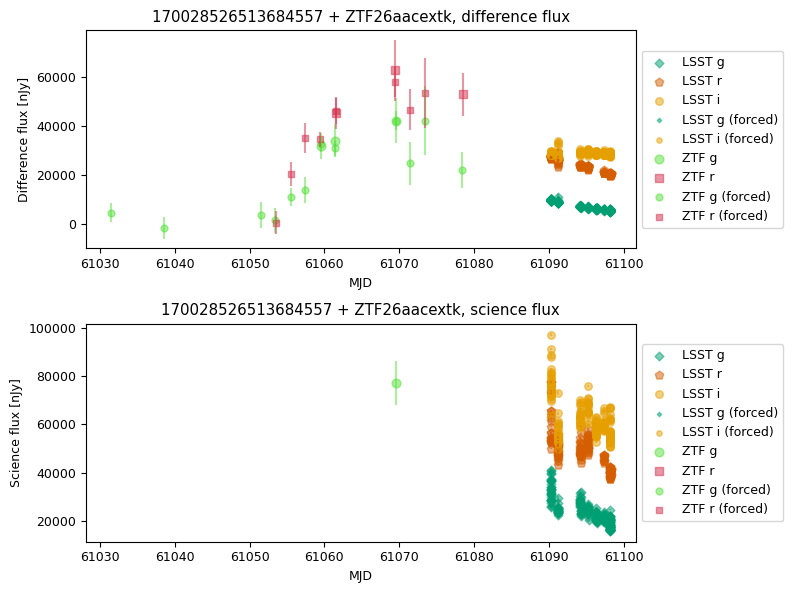

In [28]:
d_objs[sid_lsst][oid_lsst]['lc_kwargs']['show_forced'] = True
d_objs[sid_ztf][oid_ztf]['lc_kwargs']['show_forced'] = True

ms.plot_lc_1panel(d_objs=d_objs, lc_params=lc_params)

We can show these light curves using magnitude units

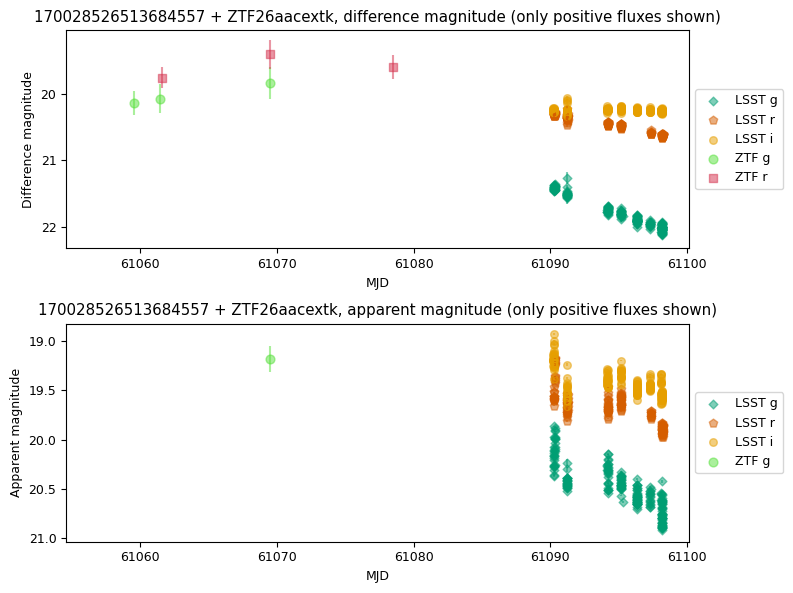

In [29]:
d_objs[sid_lsst][oid_lsst]['lc_kwargs']['show_flux'] = False
d_objs[sid_lsst][oid_lsst]['lc_kwargs']['show_forced'] = False

d_objs[sid_ztf][oid_ztf]['lc_kwargs']['show_flux'] = False
d_objs[sid_ztf][oid_ztf]['lc_kwargs']['show_forced'] = False

ms.plot_lc_1panel(d_objs=d_objs, lc_params=lc_params)

We can also show them using absolute magnitudes, assuming the redshift of the tentative host and the Planck 2018 cosmology

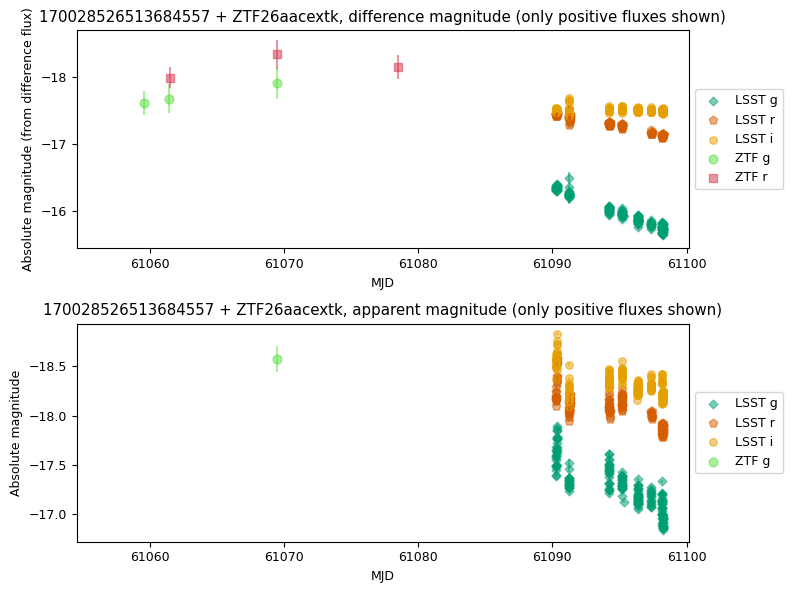

In [30]:
d_objs[sid_lsst][oid_lsst]['lc_kwargs']['show_absolute_mag'] = True
d_objs[sid_lsst][oid_lsst]['lc_kwargs']['z_obj'] = z_obj
d_objs[sid_lsst][oid_lsst]['lc_kwargs']['cosmo'] = Planck18

d_objs[sid_ztf][oid_ztf]['lc_kwargs']['show_absolute_mag'] = True
d_objs[sid_ztf][oid_ztf]['lc_kwargs']['z_obj'] = z_obj
d_objs[sid_ztf][oid_ztf]['lc_kwargs']['cosmo'] = Planck18

ms.plot_lc_1panel(d_objs=d_objs, lc_params=lc_params)

### Features <a class='anchor' id='features'></a>

We query the features computed by ALeRCE in each survey. For LSST this is done using TAP, while for ZTF is done through a direct connection to our database.

For LSST, note that we use integer identifiers for both feature names and LSST bands. We recover the original names using the mapping defined in the ```feature_name_lut``` and ```band``` lookup tables (LUTs) respectively. 

In [31]:
table_name = 'feature_name_lut'

query = '''
SELECT
    *
FROM
    alerce_tap.%s
    WHERE
        tid = %d
''' % (table_name, tid)
df_feature_names = alerce_tap.search(query).to_table().to_pandas()

display(df_feature_names)

,feature_id,feature_name,created_date,sid,tid
0,0,u-g_mean,2026-02-13,1,1
1,1,u-g_max,2026-02-13,1,1
2,2,g-r_mean,2026-02-13,1,1
3,3,g-r_max,2026-02-13,1,1
4,4,r-i_mean,2026-02-13,1,1
...,...,...,...,...,...
141,141,z-W4,2026-02-13,1,1
142,142,y-W1,2026-02-13,1,1
143,143,y-W2,2026-02-13,1,1
144,144,y-W3,2026-02-13,1,1


In [32]:
table_name = 'band'

query = '''
SELECT
    sid, tid, band, band_name, band_order
FROM
    alerce_tap.%s
WHERE
    tid = %d
ORDER BY
    sid ASC, band_order ASC
''' % (table_name, tid)

df_bands = alerce_tap.search(query).to_table().to_pandas()
display(df_bands)

,sid,tid,band,band_name,band_order
0,1,1,6,u,0
1,1,1,1,g,1
2,1,1,2,r,2
3,1,1,3,i,3
4,1,1,4,z,4
5,1,1,5,y,5
6,2,1,6,u,0
7,2,1,1,g,1
8,2,1,2,r,2
9,2,1,3,i,3


In [33]:
query = '''
SELECT
    *
FROM
    alerce_tap.feature
WHERE
    oid = %d
    AND sid = %d
''' % (oid_lsst, sid_lsst)
df_ft_lsst = alerce_tap.search(query).to_table().to_pandas()

display(df_ft_lsst)

,oid,sid,feature_id,band,version,feature_value,updated_date
0,170028526513684557,1,2,0,1,1.315615,2026-03-04
1,170028526513684557,1,3,0,1,1.038762,2026-03-04
2,170028526513684557,1,4,0,1,0.228292,2026-03-04
3,170028526513684557,1,5,0,1,0.158628,2026-03-04
4,170028526513684557,1,12,0,1,0.808968,2026-03-04
...,...,...,...,...,...,...,...
258,170028526513684557,1,117,2,1,-0.744105,2026-03-04
259,170028526513684557,1,117,3,1,0.105211,2026-03-04
260,170028526513684557,1,118,1,1,24.089010,2026-03-04
261,170028526513684557,1,118,2,1,22.774665,2026-03-04


We create a function to apply the mapping between columns, useful for both LUTs

In [34]:
def add_mapped_column(df=None, df_lut=None,
                      col=None, col_mapped=None):
    def map_column(row):
        row_index = (row['sid'], row[col]) \
                    if 'sid' in df_lut.columns \
                    else row[col]
        col_new = df_aux.loc[
            row_index, col_mapped] \
            if row_index in df_aux.index \
            else None
        return col_new
    
    df = df.copy()

    if len(df) > 0:
        row_index = ['sid', col] if 'sid' in df_lut.columns else col
        df_aux = df_lut.set_index(row_index).copy()
        
        df[col_mapped] = df.apply(
            lambda row: map_column(row),
            axis=1)
    else:
        df[col_mapped] = None

    return df

In [35]:
df_ft_lsst = add_mapped_column(
    df=df_ft_lsst,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)

In [36]:
df_ft_lsst = add_mapped_column(
    df=df_ft_lsst,
    df_lut=df_feature_names,
    col='feature_id',
    col_mapped='feature_name')

We show the list of features retrieved (note that features with NaN values are not stored)

In [37]:
pd.set_option('display.max_rows', None)
display(df_ft_lsst)
pd.set_option('display.max_rows', 30)

,oid,sid,feature_id,band,version,feature_value,updated_date,band_name,feature_name
0,170028526513684557,1,2,0,1,1.315615e+00,2026-03-04,None,g-r_mean
1,170028526513684557,1,3,0,1,1.038762e+00,2026-03-04,None,g-r_max
2,170028526513684557,1,4,0,1,2.282916e-01,2026-03-04,None,r-i_mean
3,170028526513684557,1,5,0,1,1.586284e-01,2026-03-04,None,r-i_max
4,170028526513684557,1,12,0,1,8.089678e-01,2026-03-04,None,g-r_mean_corr
5,170028526513684557,1,13,0,1,6.920177e-01,2026-03-04,None,g-r_max_corr
6,170028526513684557,1,14,0,1,2.599193e-01,2026-03-04,None,r-i_mean_corr
7,170028526513684557,1,15,0,1,2.432009e-01,2026-03-04,None,r-i_max_corr
8,170028526513684557,1,20,0,1,7.993832e+00,2026-03-04,None,Timespan
9,170028526513684557,1,21,0,1,-9.851729e-01,2026-03-04,None,Coordinate_x


For ZTF, we open the connection and do an SQL query and show the list of features retrieved

In [38]:
url = "https://raw.githubusercontent.com/alercebroker/usecases/master/alercereaduser_v4.json"
params = requests.get(url).json()['params']

In [39]:
engine = sa.create_engine('postgresql+psycopg2://' + params['user'] \
                          + ':' + params['password'] + '@' + params['host'] \
                          + '/' + params['dbname'])
conn_ztf = engine.connect()

In [40]:
query = '''
SELECT
    *
FROM
    feature
WHERE
    oid = '%s'
''' % oid_ztf

df_feat_ztf = pd.read_sql_query(query, conn_ztf)

pd.set_option('display.max_rows', None)
display(df_feat_ztf)
pd.set_option('display.max_rows', 30)

,oid,name,value,fid,version
0,ZTF26aacextk,g-r_mean,0.428631,12,27.5.6
1,ZTF26aacextk,g-r_max,0.427900,12,27.5.6
2,ZTF26aacextk,g-r_mean_corr,NaN,12,27.5.6
3,ZTF26aacextk,g-r_max_corr,NaN,12,27.5.6
4,ZTF26aacextk,W1-W2,NaN,0,27.5.6
5,ZTF26aacextk,W2-W3,NaN,0,27.5.6
6,ZTF26aacextk,W3-W4,NaN,0,27.5.6
7,ZTF26aacextk,g-W1,NaN,0,27.5.6
8,ZTF26aacextk,r-W1,NaN,0,27.5.6
9,ZTF26aacextk,g-W2,NaN,0,27.5.6


We close the connection

In [41]:
conn_ztf.close()